# Mushroom Classification Project Notebook

This notebook runs the full project pipeline step-by-step using the modular files in `src/`:
- Dataset understanding
- Preprocessing
- Outlier detection
- EDA + visualizations
- Multiple classification models
- Feature importance + report generation

In [8]:
from pathlib import Path
import sys
import importlib

import pandas as pd
import seaborn as sns
from IPython.display import Image, Markdown, display
from sklearn.model_selection import train_test_split

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / 'src').exists() and (REPO_ROOT.parent / 'src').exists():
    REPO_ROOT = REPO_ROOT.parent

SRC_PATH = REPO_ROOT / 'src'
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

import step_00_io
import step_01_preprocessing
import step_02_outlier_detection
import step_03_eda_analysis
import step_04_modeling
import step_05_reporting

importlib.reload(step_00_io)
importlib.reload(step_01_preprocessing)
importlib.reload(step_02_outlier_detection)
importlib.reload(step_03_eda_analysis)
importlib.reload(step_04_modeling)
importlib.reload(step_05_reporting)

from step_00_io import ensure_output_dirs
from step_01_preprocessing import preprocess_dataframe, preprocess_dataframe_class_mode
from step_02_outlier_detection import detect_outliers
from step_03_eda_analysis import build_dataset_profile, build_missing_summary, create_eda_artifacts
from step_04_modeling import (
    get_selected_model_names,
    train_selected_models,
    save_model_comparison_plot,
    save_all_confusion_matrices,
    extract_random_forest_feature_importance,
    save_feature_importance_plot,
)
from step_05_reporting import build_milestone_1_report, build_final_project_report

DATASET_PATH = REPO_ROOT / 'Mushroom Dataset' / 'mushrooms 2.csv'
OUTPUT_PATH = REPO_ROOT / 'outputs'
OUTLIER_CONTAMINATION = 0.01
SEED = 42

sns.set_theme(style='whitegrid')
dirs = ensure_output_dirs(OUTPUT_PATH)
RUN_OUTPUT_DIR = dirs['run_root']

print(f'Repo root: {REPO_ROOT}')
print(f'Dataset path: {DATASET_PATH}')
print(f'Output root: {OUTPUT_PATH}')
print(f'Current run folder: {RUN_OUTPUT_DIR}')

Repo root: c:\Users\Ahmed Fahmy\Downloads\Projects\Data Mining\mushroom-classifier-project
Dataset path: c:\Users\Ahmed Fahmy\Downloads\Projects\Data Mining\mushroom-classifier-project\Mushroom Dataset\mushrooms 2.csv
Output root: c:\Users\Ahmed Fahmy\Downloads\Projects\Data Mining\mushroom-classifier-project\outputs
Current run folder: c:\Users\Ahmed Fahmy\Downloads\Projects\Data Mining\mushroom-classifier-project\outputs\20260304_204340_310404


## 1) Load Dataset and Understand Features

In [16]:
df = pd.read_csv(DATASET_PATH)

if 'class' not in df.columns:
    raise ValueError("Dataset must contain a 'class' column.")

target_col = 'class'
feature_cols = [col for col in df.columns if col != target_col]

print('Shape:', df.shape)
print('Number of features:', len(feature_cols))
print('Class counts:')
display(df[target_col].value_counts())
display(df.head())

Shape: (8124, 23)
Number of features: 22
Class counts:


class
e    4208
p    3916
Name: count, dtype: int64

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


## 2) Preprocessing Summaries (Milestone 1)

In [10]:
dataset_profile = build_dataset_profile(df, target_col=target_col)
missing_table = build_missing_summary(df)

dataset_profile.to_csv(dirs['tables'] / 'dataset_profile.csv', index=False)
missing_table.to_csv(dirs['tables'] / 'missing_and_unique_summary.csv', index=False)

processed_df_class_mode = preprocess_dataframe_class_mode(df, target_col=target_col)
processed_df_class_mode.to_csv(dirs['tables'] / 'preprocessed_dataset_class_mode.csv', index=False)

display(dataset_profile)
display(missing_table.head(10))
display(processed_df_class_mode.head())

,metric,value
0,rows,8124
1,columns,23
2,duplicate_rows,0
3,class_edible_count,4208
4,class_poisonous_count,3916


,column,missing_count_after_question_mark_replace,unknown_question_mark_count,unique_values
0,class,0,0,2
1,cap-shape,0,0,6
2,cap-surface,0,0,4
3,cap-color,0,0,10
4,bruises,0,0,2
5,odor,0,0,9
6,gill-attachment,0,0,2
7,gill-spacing,0,0,2
8,gill-size,0,0,2
9,gill-color,0,0,12


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


## 3) Apply Preprocessing and Detect Outliers

In [11]:
processed_df = preprocess_dataframe(df, target_col=target_col)
processed_df.to_csv(dirs['tables'] / 'preprocessed_dataset.csv', index=False)

outlier_df = detect_outliers(processed_df[feature_cols], contamination=OUTLIER_CONTAMINATION, random_state=SEED)
outlier_df.to_csv(dirs['tables'] / 'outlier_flags.csv', index=True)

outlier_summary = pd.DataFrame({
    'method': ['rarity', 'isolation_forest', 'combined_union'],
    'outlier_count': [
        int(outlier_df['rarity_flag'].sum()),
        int(outlier_df['isolation_forest_flag'].sum()),
        int(outlier_df['combined_outlier_flag'].sum()),
    ],
})
outlier_summary['outlier_percent'] = (outlier_summary['outlier_count'] / len(outlier_df) * 100).round(2)
outlier_summary.to_csv(dirs['tables'] / 'outlier_summary.csv', index=False)

display(outlier_summary)

,method,outlier_count,outlier_percent
0,rarity,82,1.01
1,isolation_forest,82,1.01
2,combined_union,106,1.30


## 4) EDA and Visualization

,feature,cramers_v_with_class
4,odor,0.970558
19,spore-print-color,0.752036
8,gill-color,0.679877
18,ring-type,0.602900
11,stalk-surface-above-ring,0.587666
12,stalk-surface-below-ring,0.574551
7,gill-size,0.539677
13,stalk-color-above-ring,0.523943
14,stalk-color-below-ring,0.513799
3,bruises,0.501188


EDA plots saved to: c:\Users\Ahmed Fahmy\Downloads\Projects\Data Mining\mushroom-classifier-project\outputs\20260304_204340_310404\plots


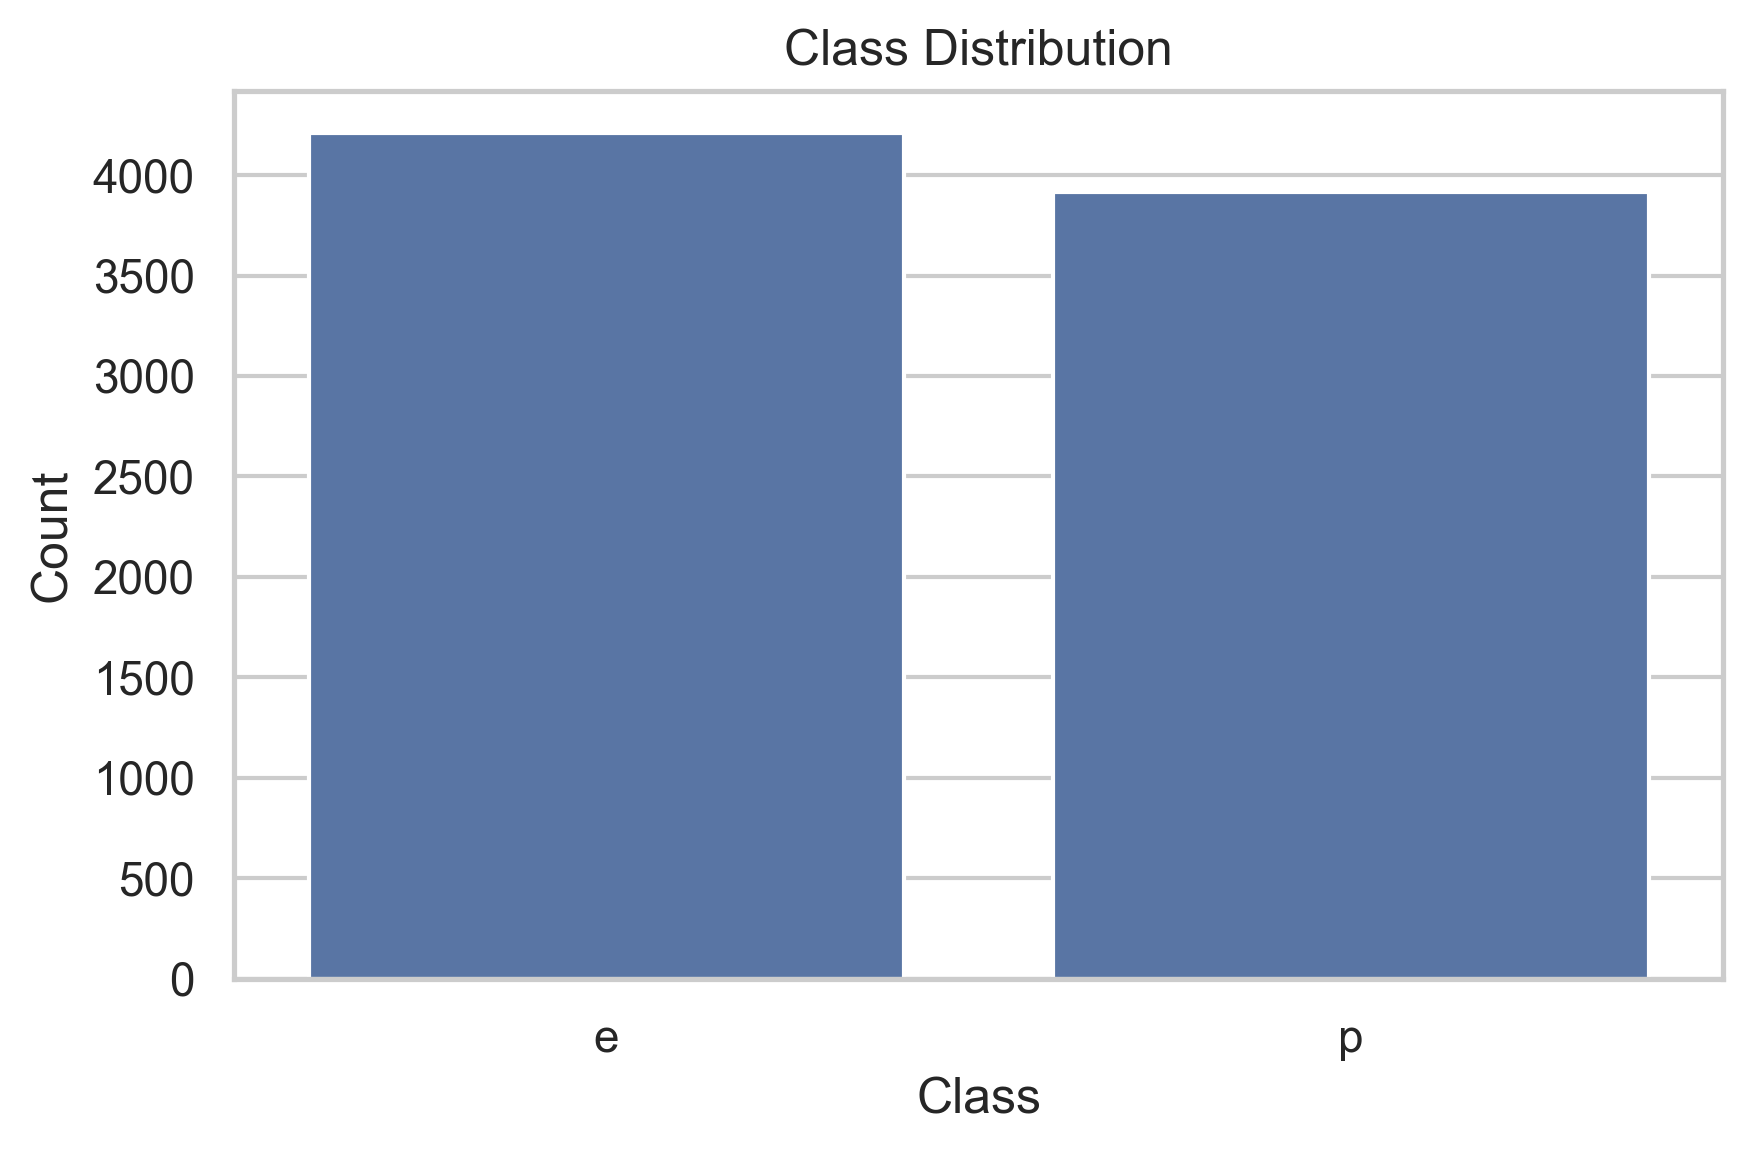

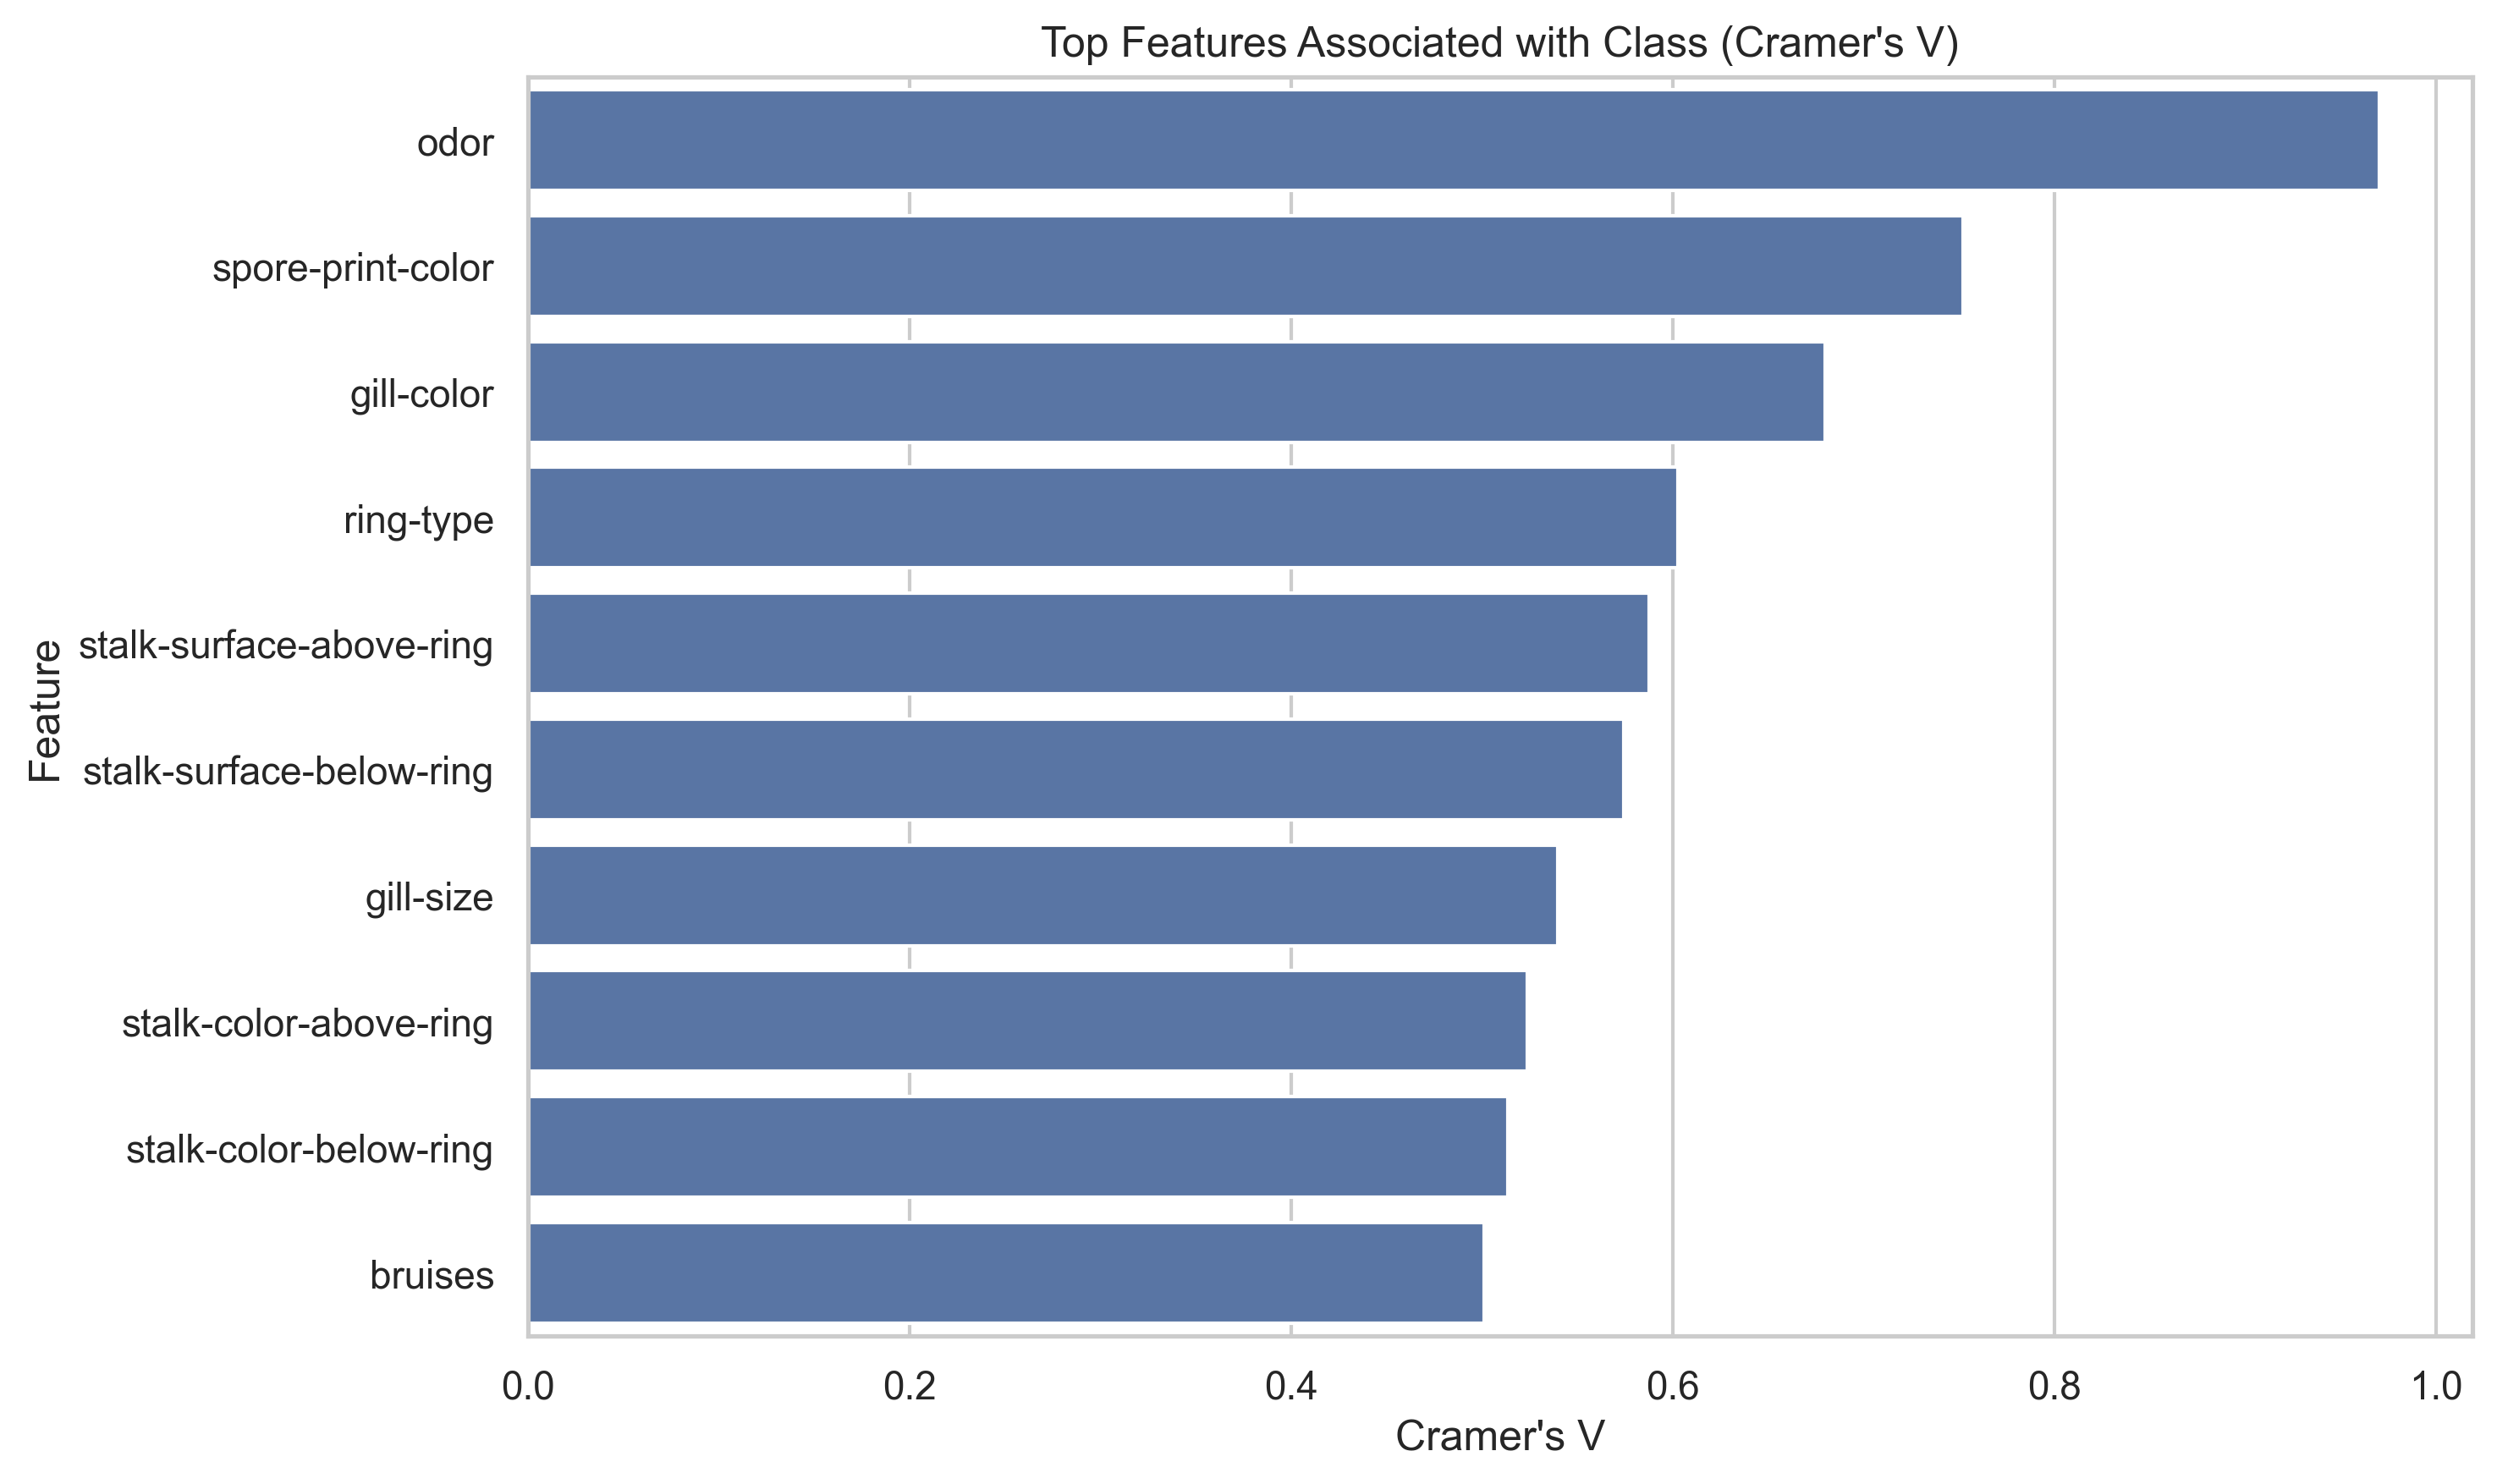

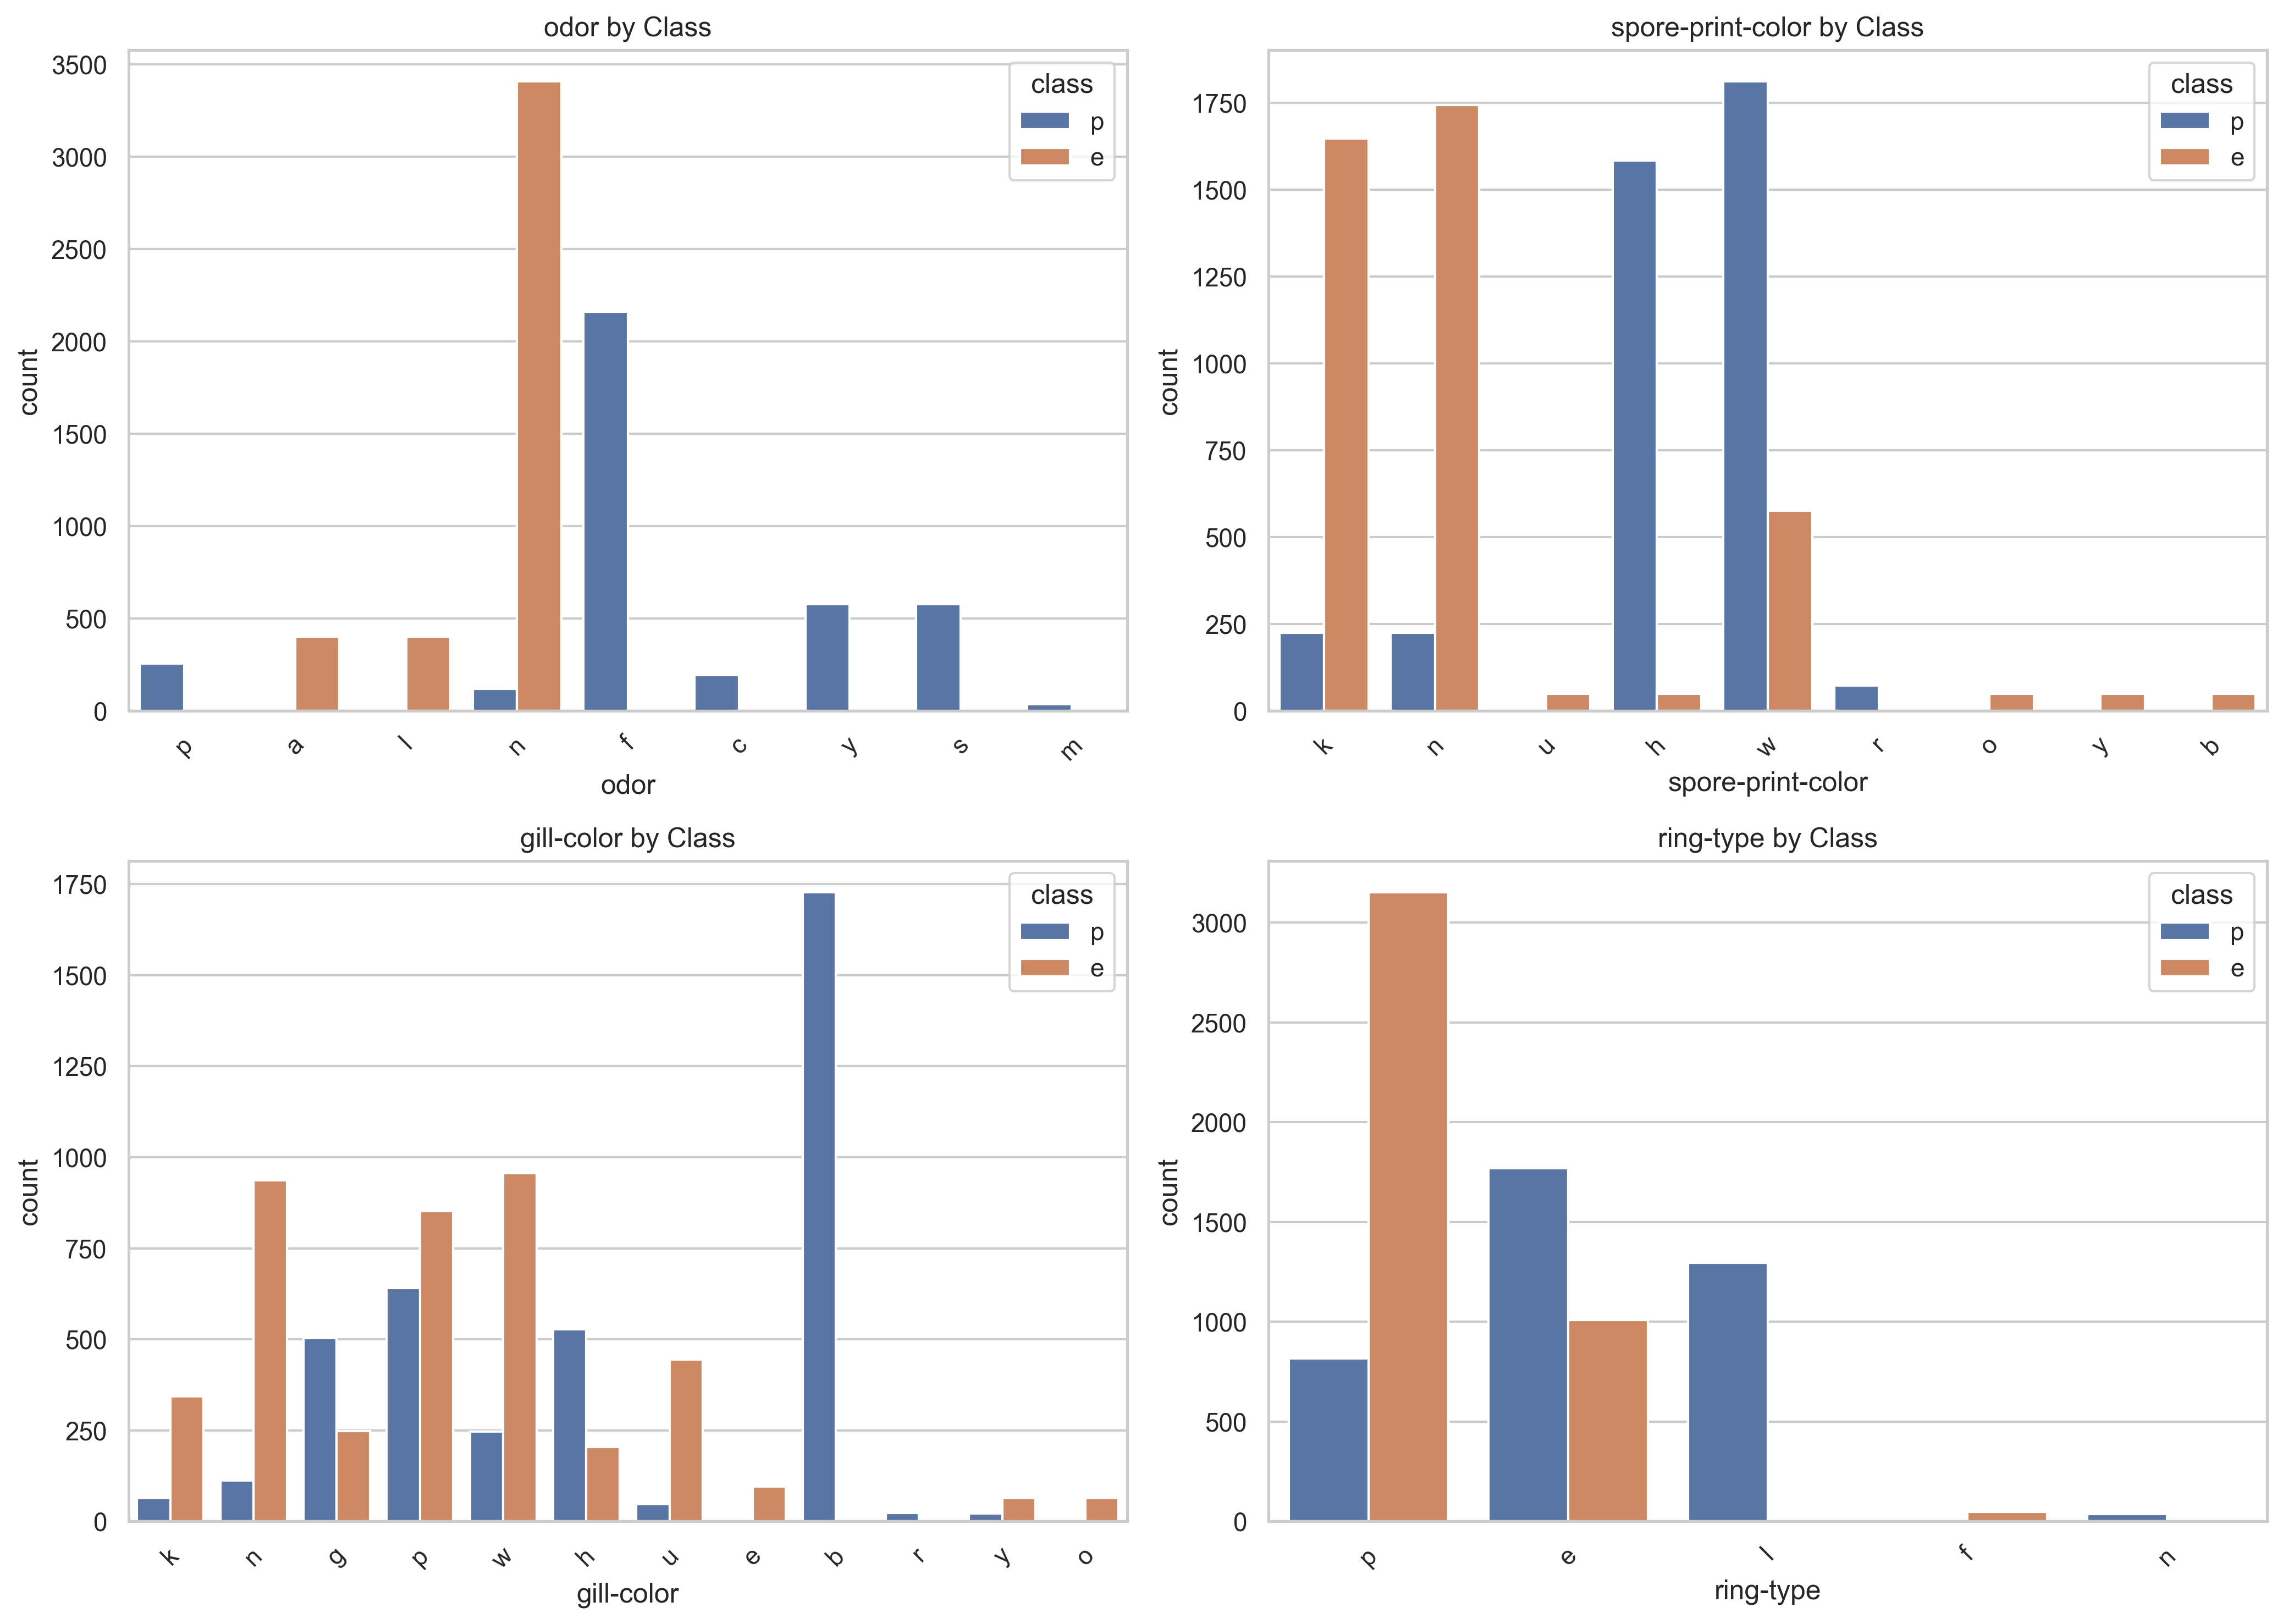

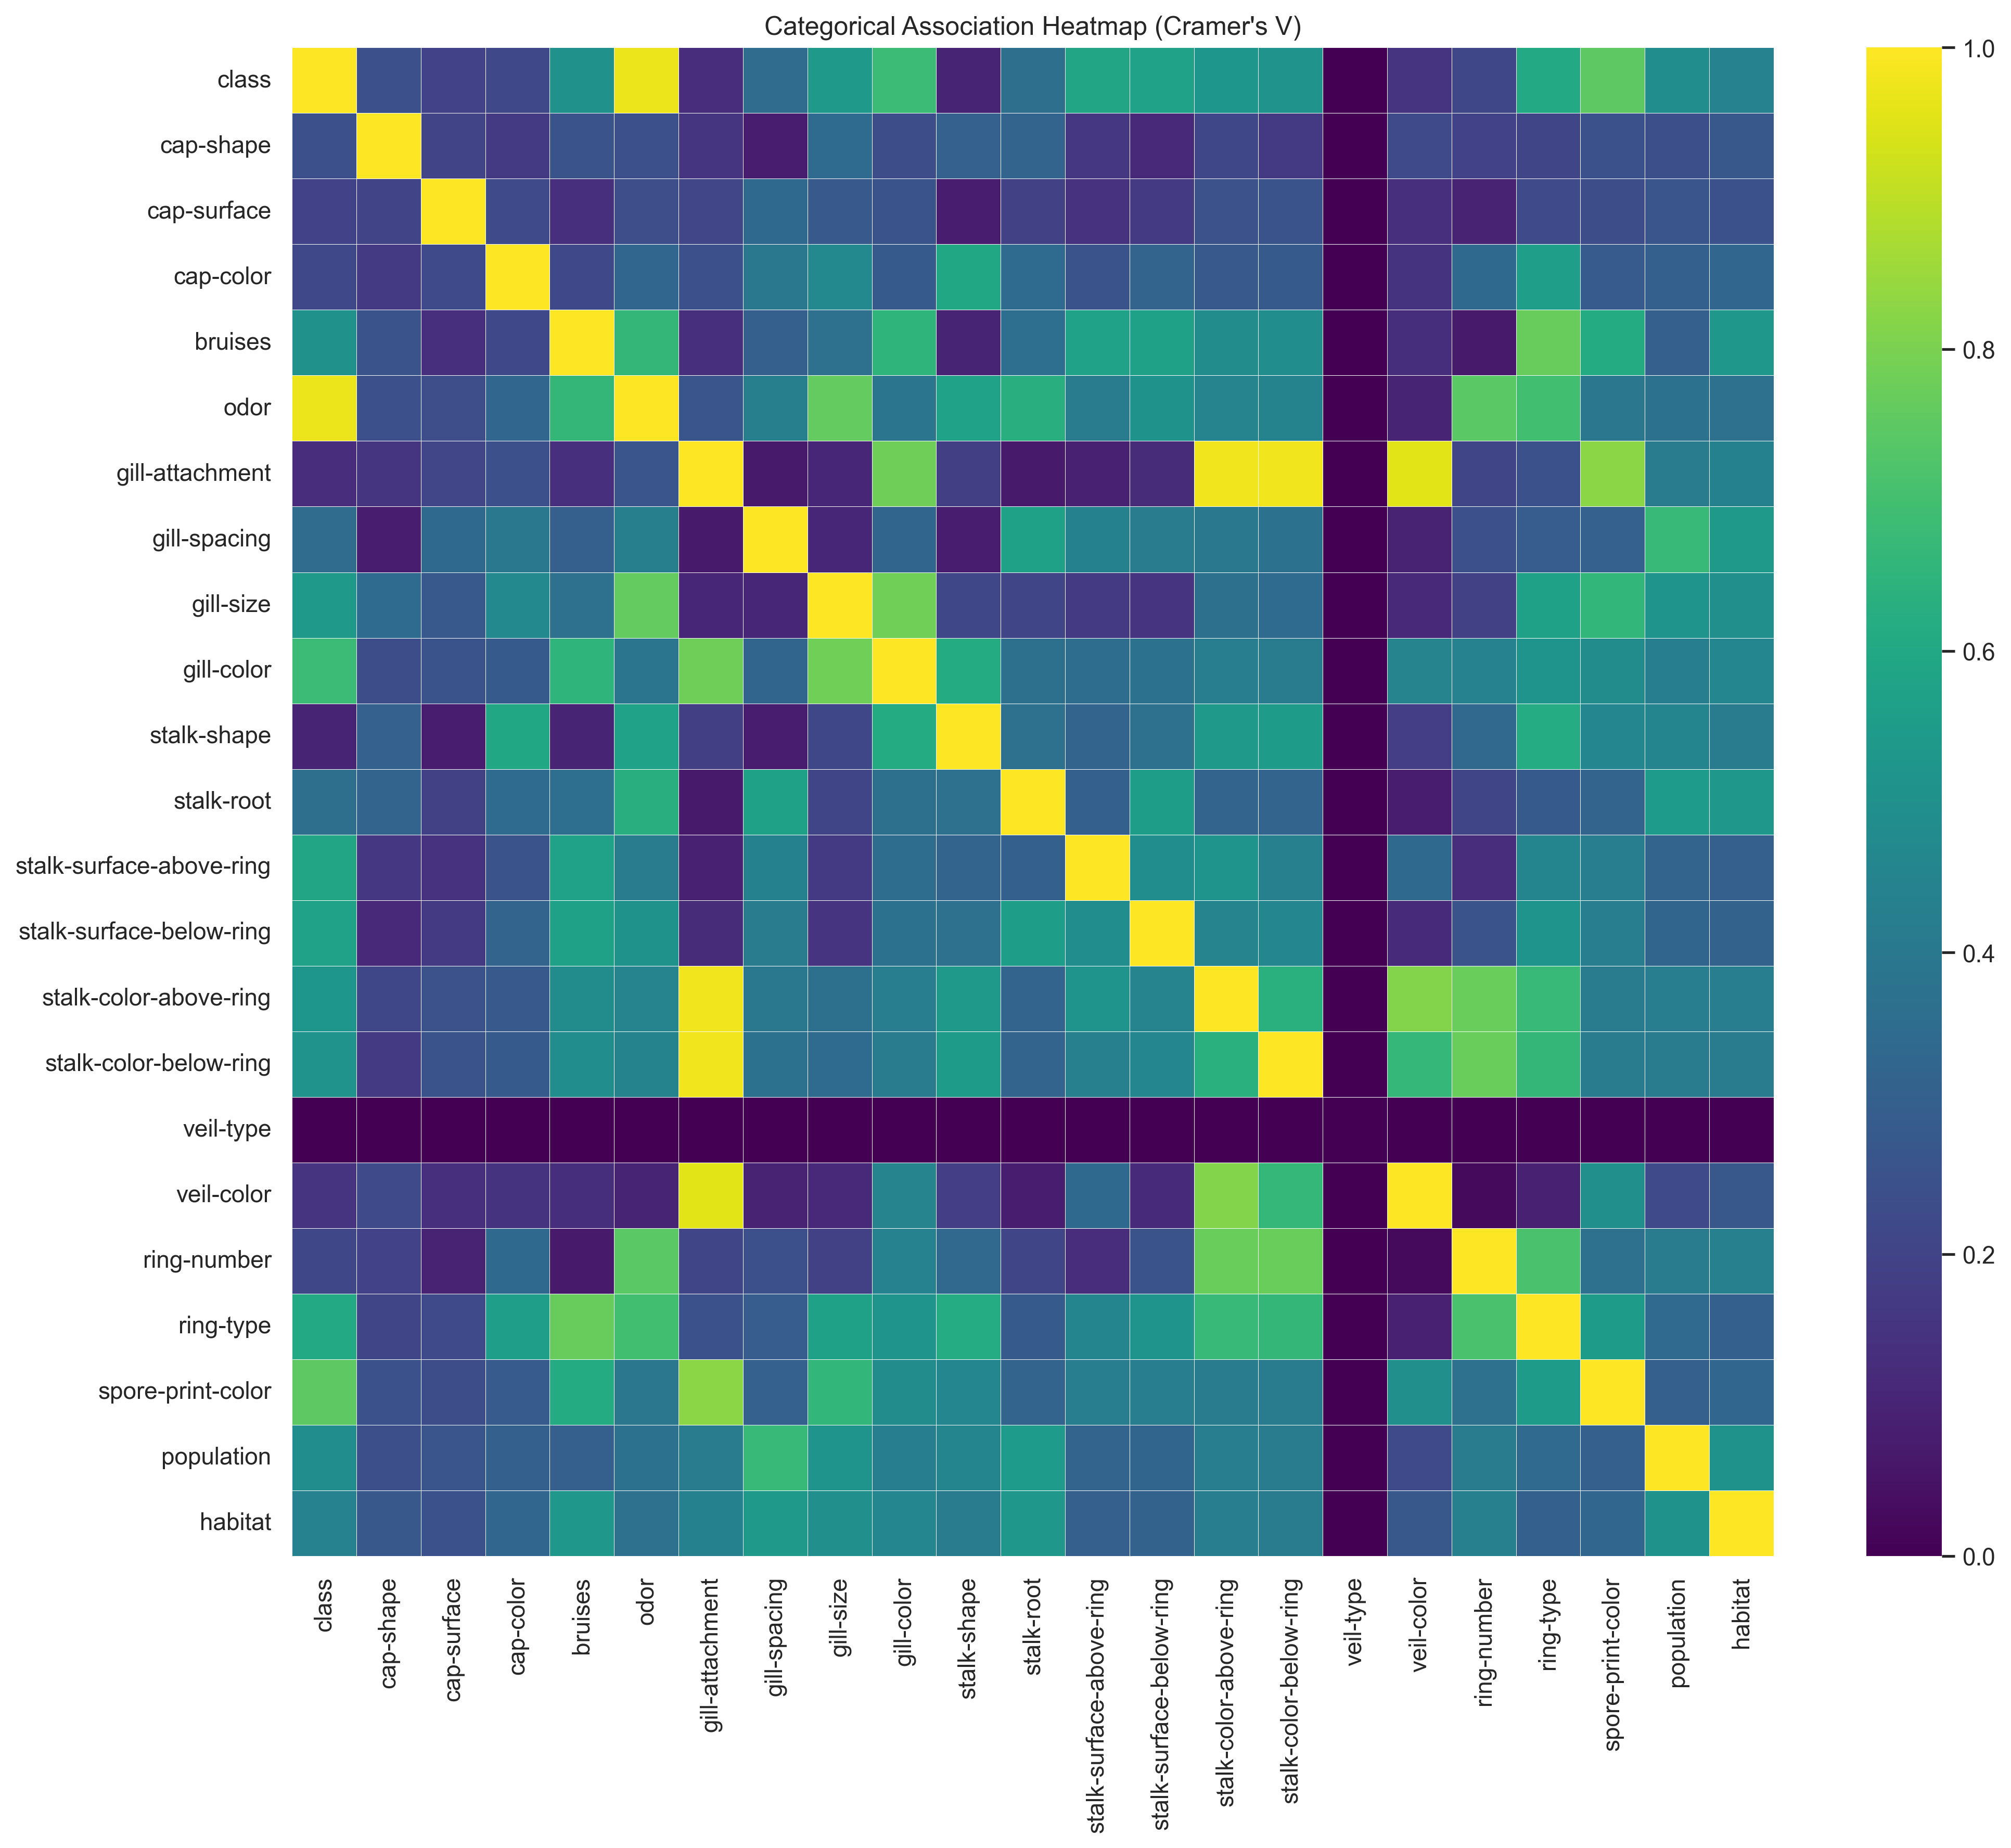

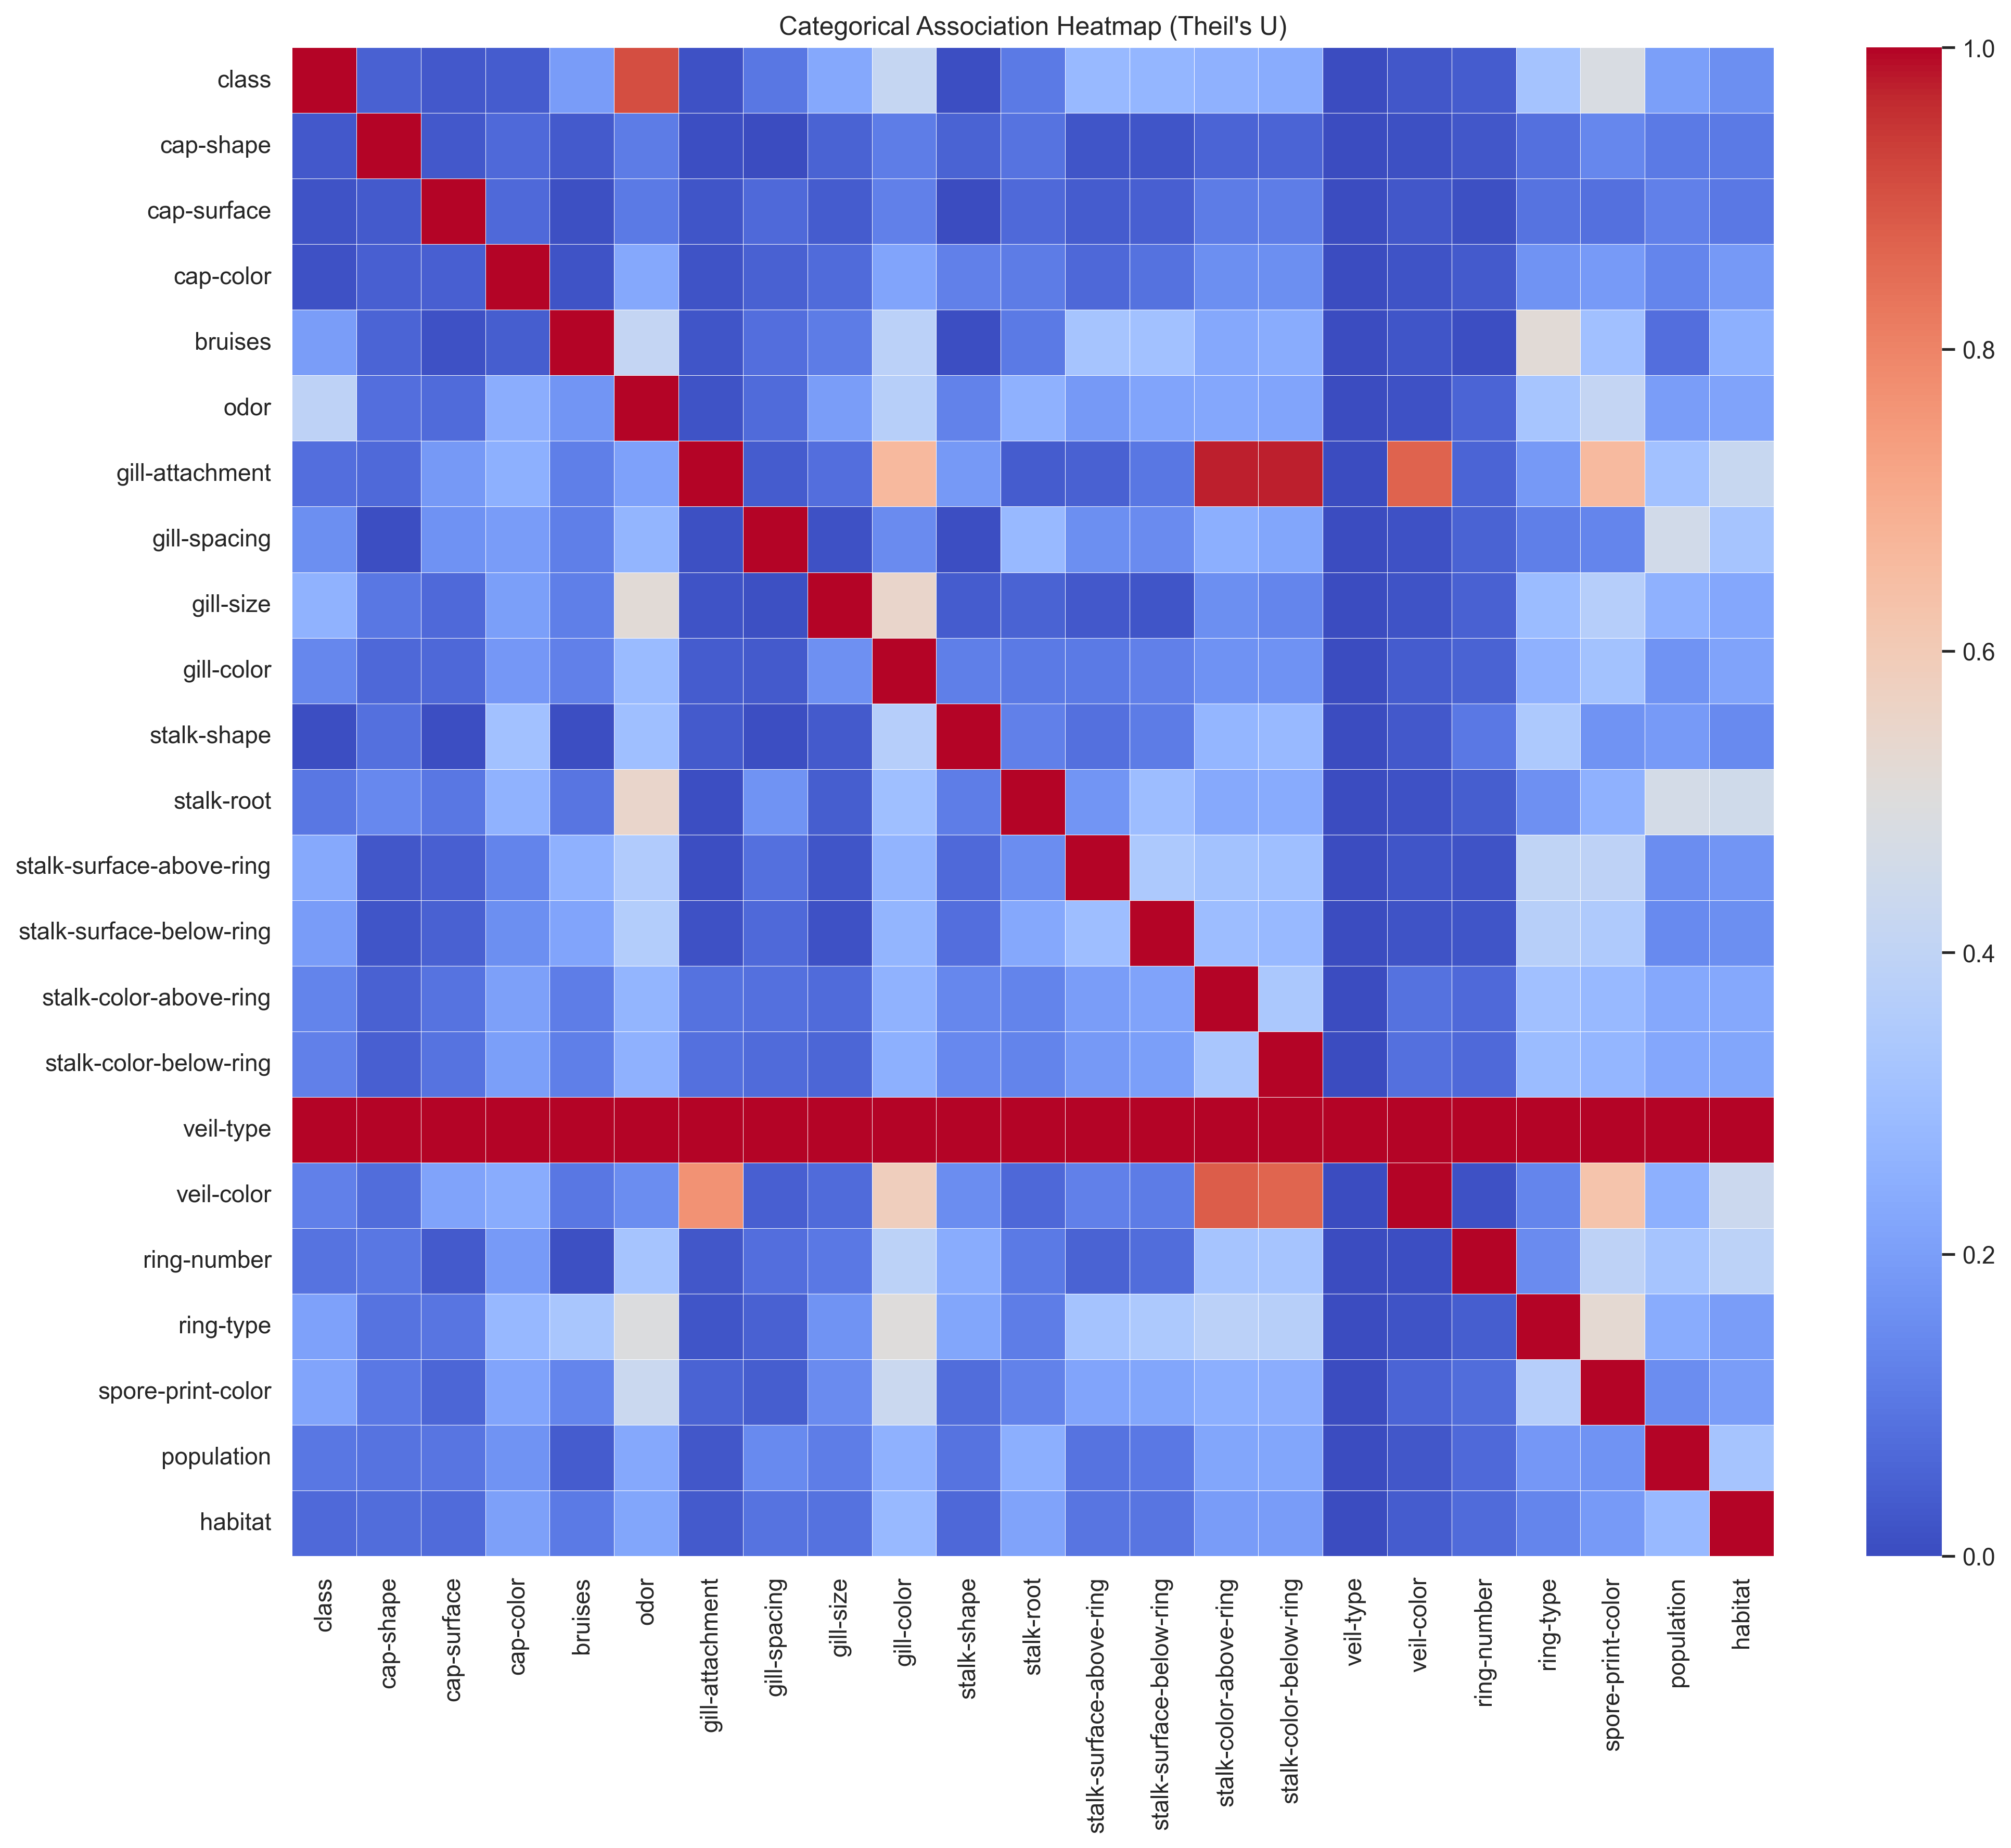

In [12]:
assoc_df = create_eda_artifacts(
    processed_df=processed_df,
    target_col=target_col,
    feature_cols=feature_cols,
    plots_dir=dirs['plots'],
    tables_dir=dirs['tables'],
)

display(assoc_df.head(10))
print('EDA plots saved to:', dirs['plots'])

display(Image(filename=str(dirs['plots'] / 'class_distribution.png')))
display(Image(filename=str(dirs['plots'] / 'top_feature_associations.png')))
display(Image(filename=str(dirs['plots'] / 'top_feature_countplots.png')))
display(Image(filename=str(dirs['plots'] / 'categorical_association_heatmap.png')))
display(Image(filename=str(dirs['plots'] / 'theils_u_heatmap.png')))

## 5) Train Selected Model (One-Line Switch)

Selected models from step_04_modeling.py: ['RandomForest']


,model,accuracy,precision_poisonous,recall_poisonous,f1_poisonous,cv_accuracy_mean,cv_accuracy_std
0,RandomForest,1.0,1.0,1.0,1.0,0.904324,0.127532


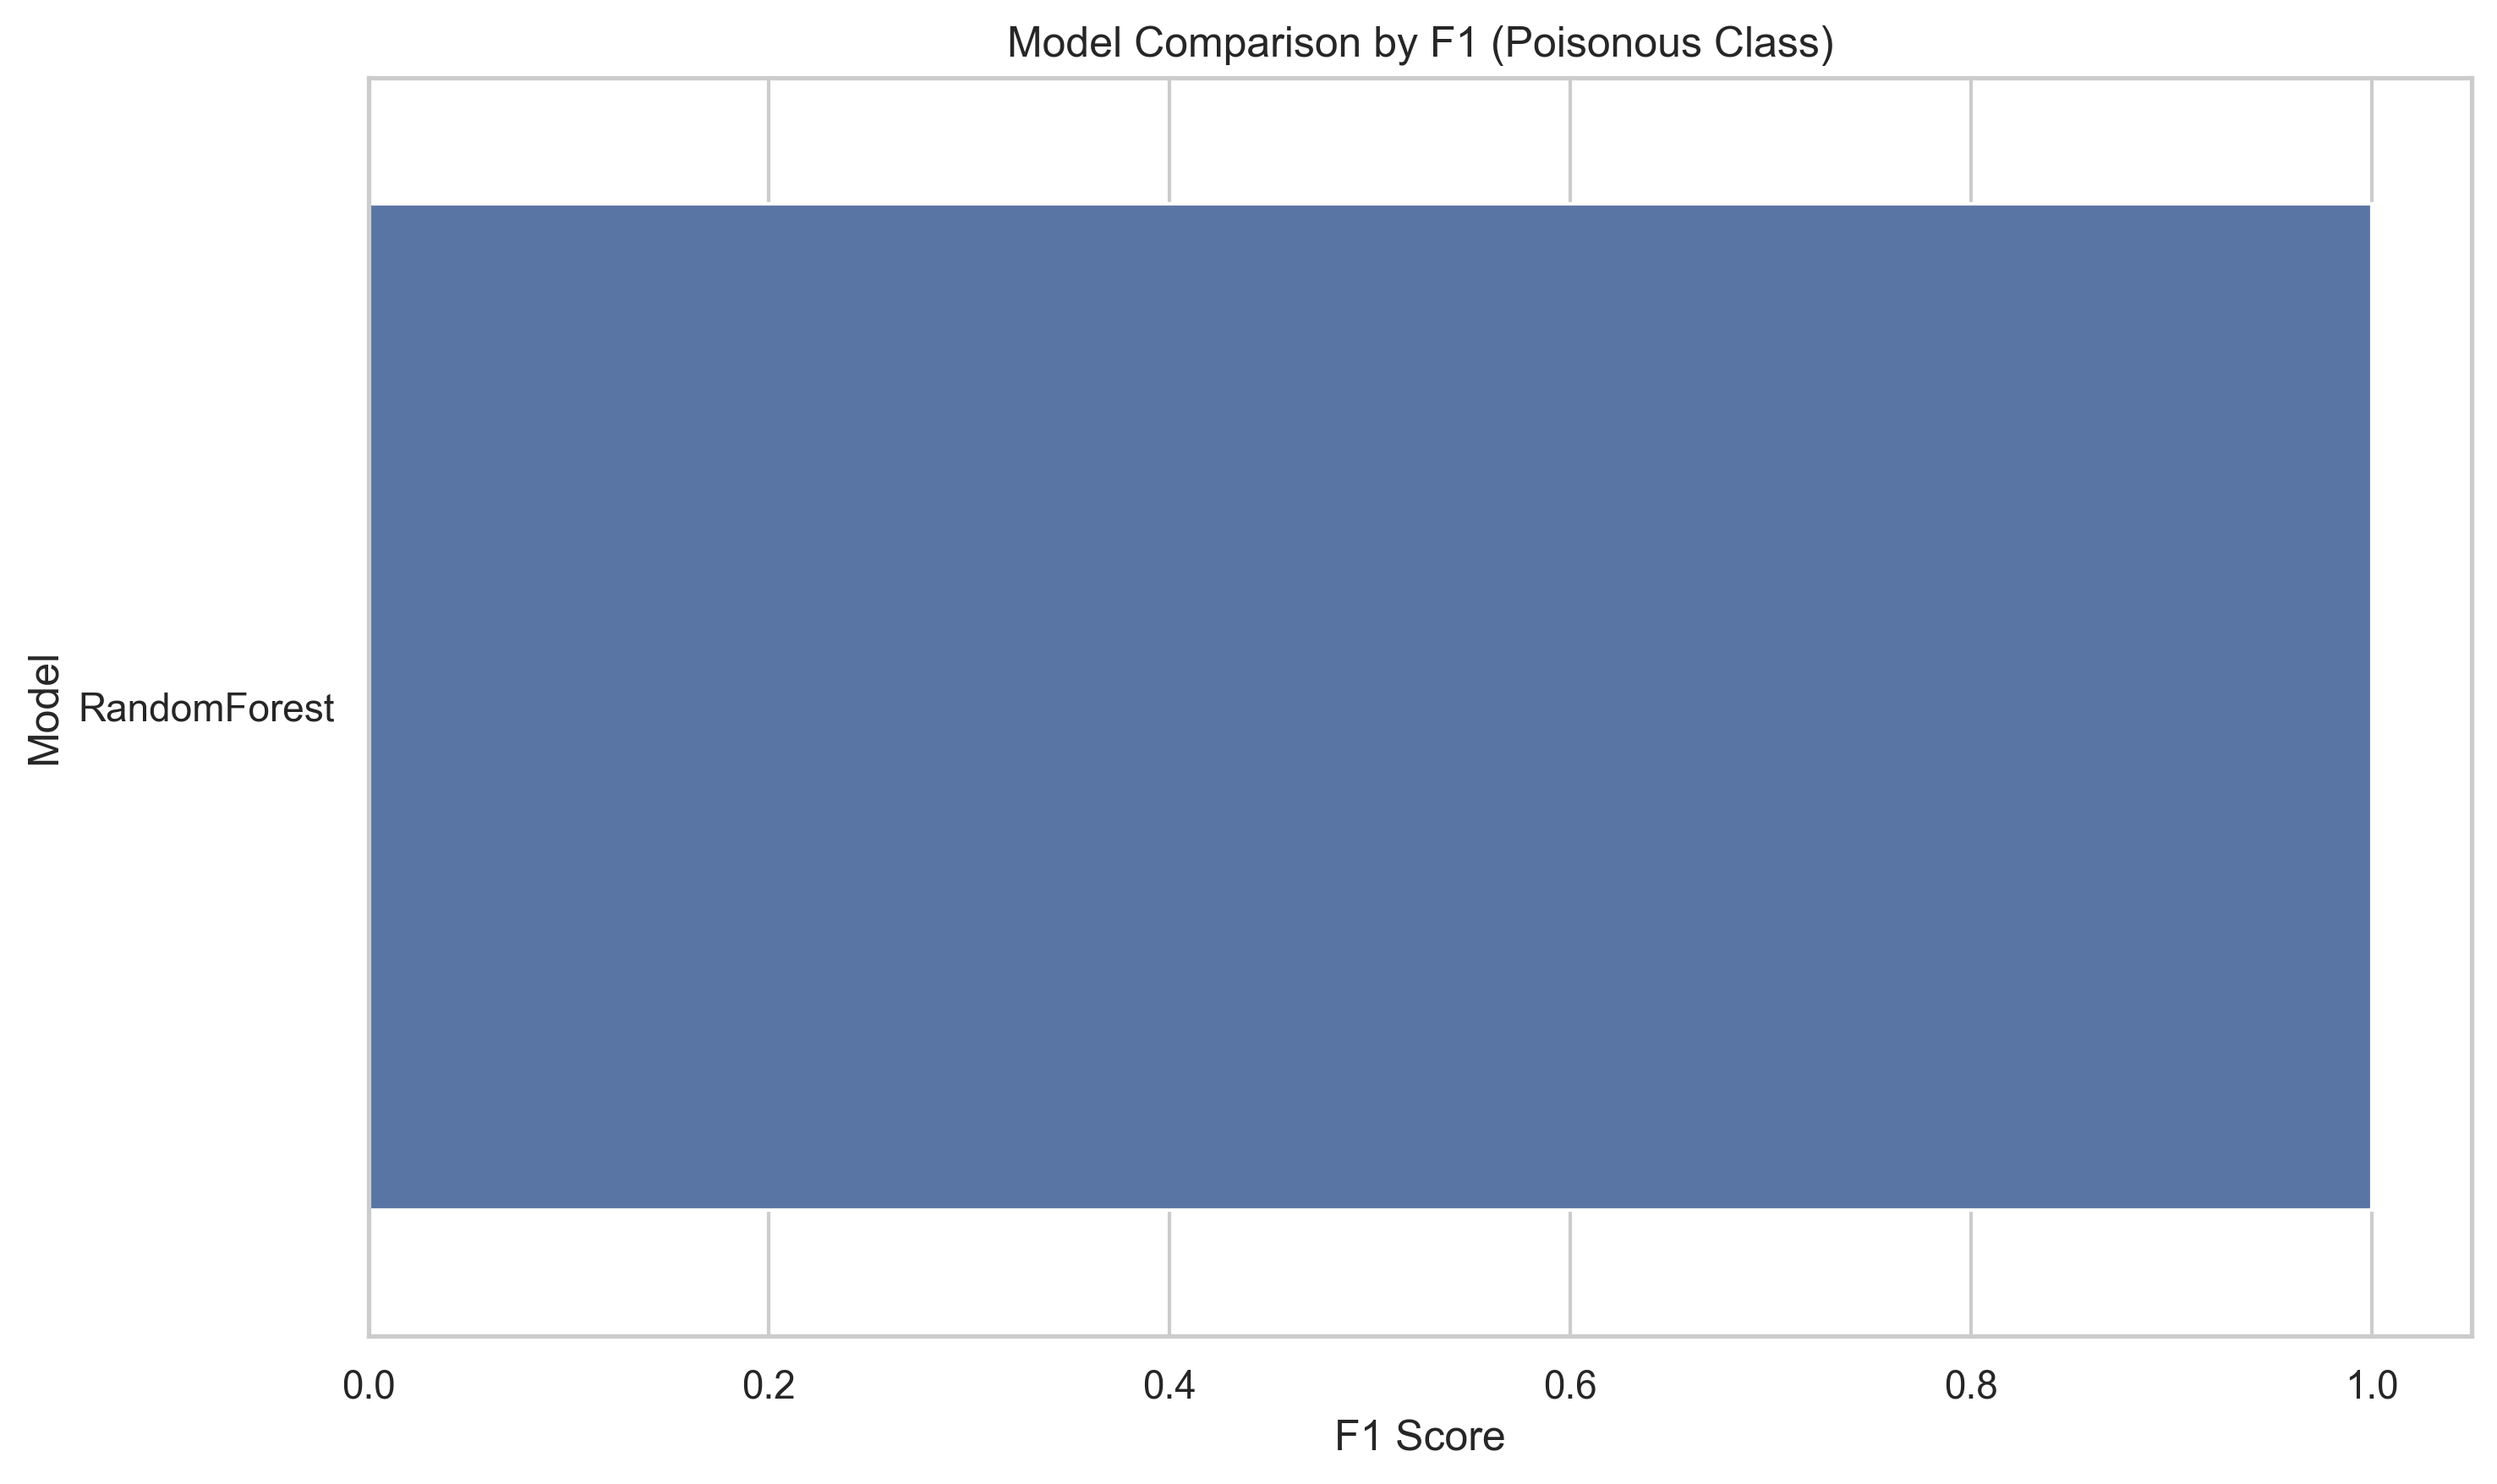

**confusion_matrix_randomforest.png**

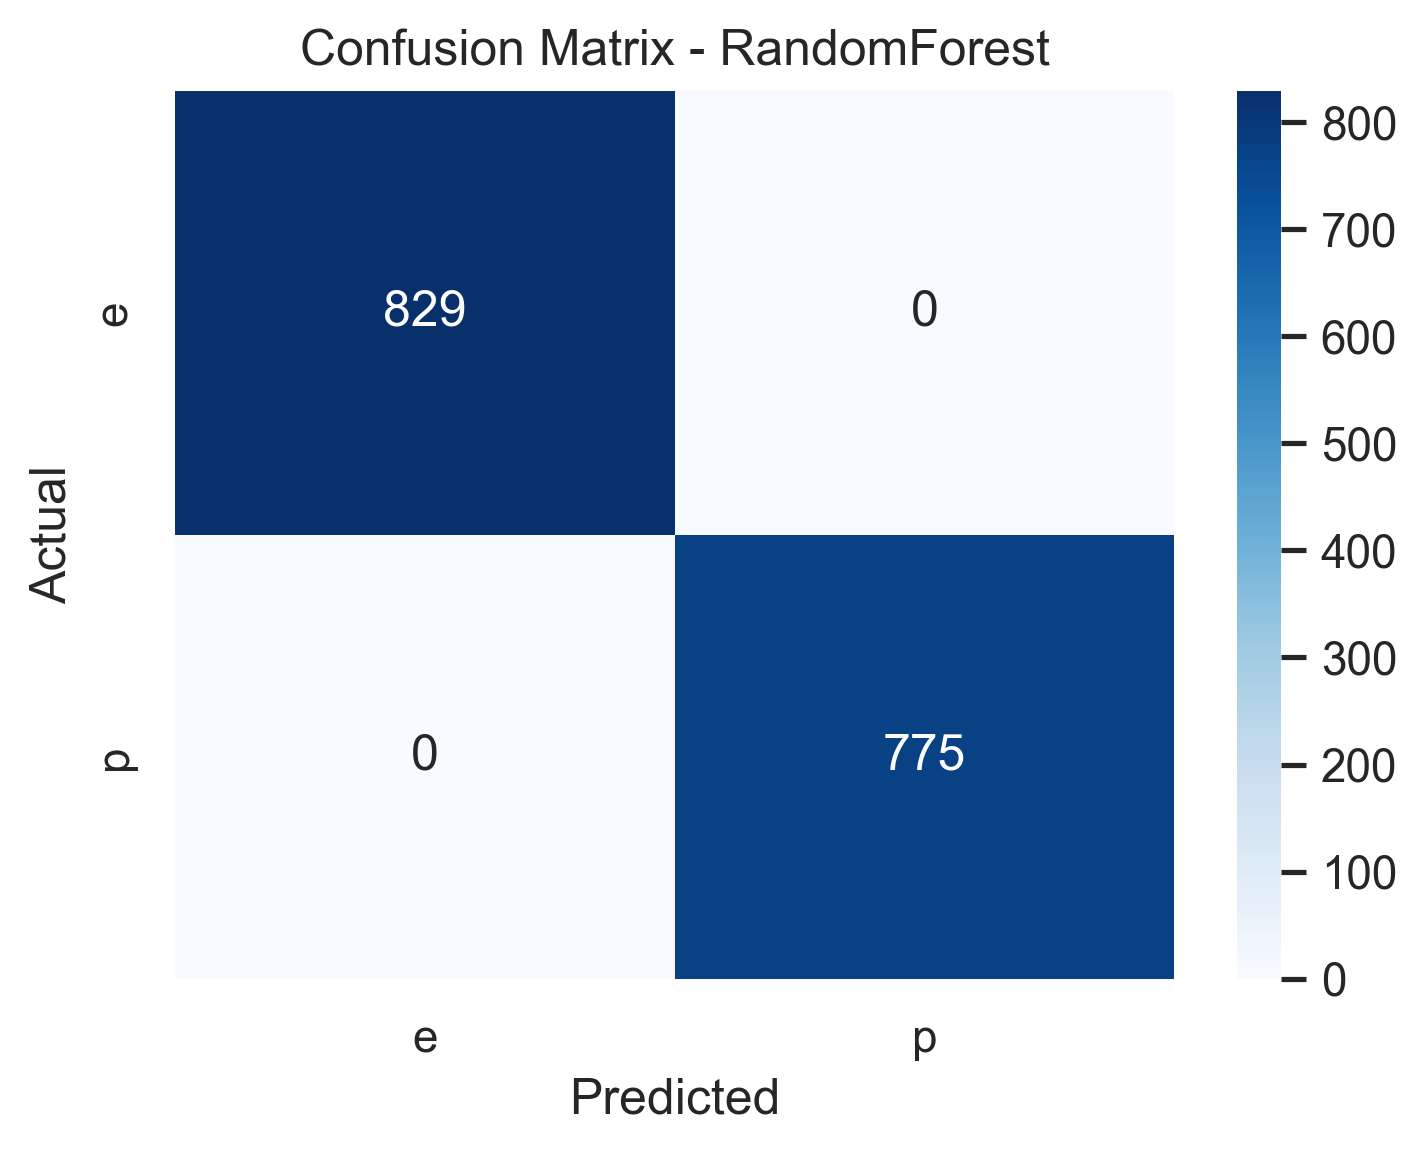

In [13]:
model_df = processed_df.loc[~outlier_df['combined_outlier_flag']].copy()
X = model_df[feature_cols]
y = model_df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

selected_models = get_selected_model_names(random_state=SEED)
print('Selected models from step_04_modeling.py:', selected_models)

comparison_df, pipelines = train_selected_models(
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    full_X=X,
    full_y=y,
    feature_columns=feature_cols,
    model_names=selected_models,
    random_state=SEED,
)

comparison_df.to_csv(dirs['tables'] / 'model_comparison.csv', index=False)
save_model_comparison_plot(comparison_df, dirs['plots'] / 'model_comparison_f1.png')
save_all_confusion_matrices(pipelines, X_test, y_test, dirs['plots'])

display(comparison_df)
display(Image(filename=str(dirs['plots'] / 'model_comparison_f1.png')))

for confusion_path in sorted(dirs['plots'].glob('confusion_matrix_*.png')):
    display(Markdown(f"**{confusion_path.name}**"))
    display(Image(filename=str(confusion_path)))

## 6) Prominent Factors + Reports

,encoded_feature,importance
26,odor_n,0.127085
24,odor_f,0.073359
35,gill-size_n,0.061867
34,gill-size_b,0.061592
88,spore-print-color_h,0.050367
59,stalk-surface-below-ring_k,0.046042
55,stalk-surface-above-ring_k,0.042373
21,bruises_t,0.035955
36,gill-color_b,0.034112
86,ring-type_p,0.029936


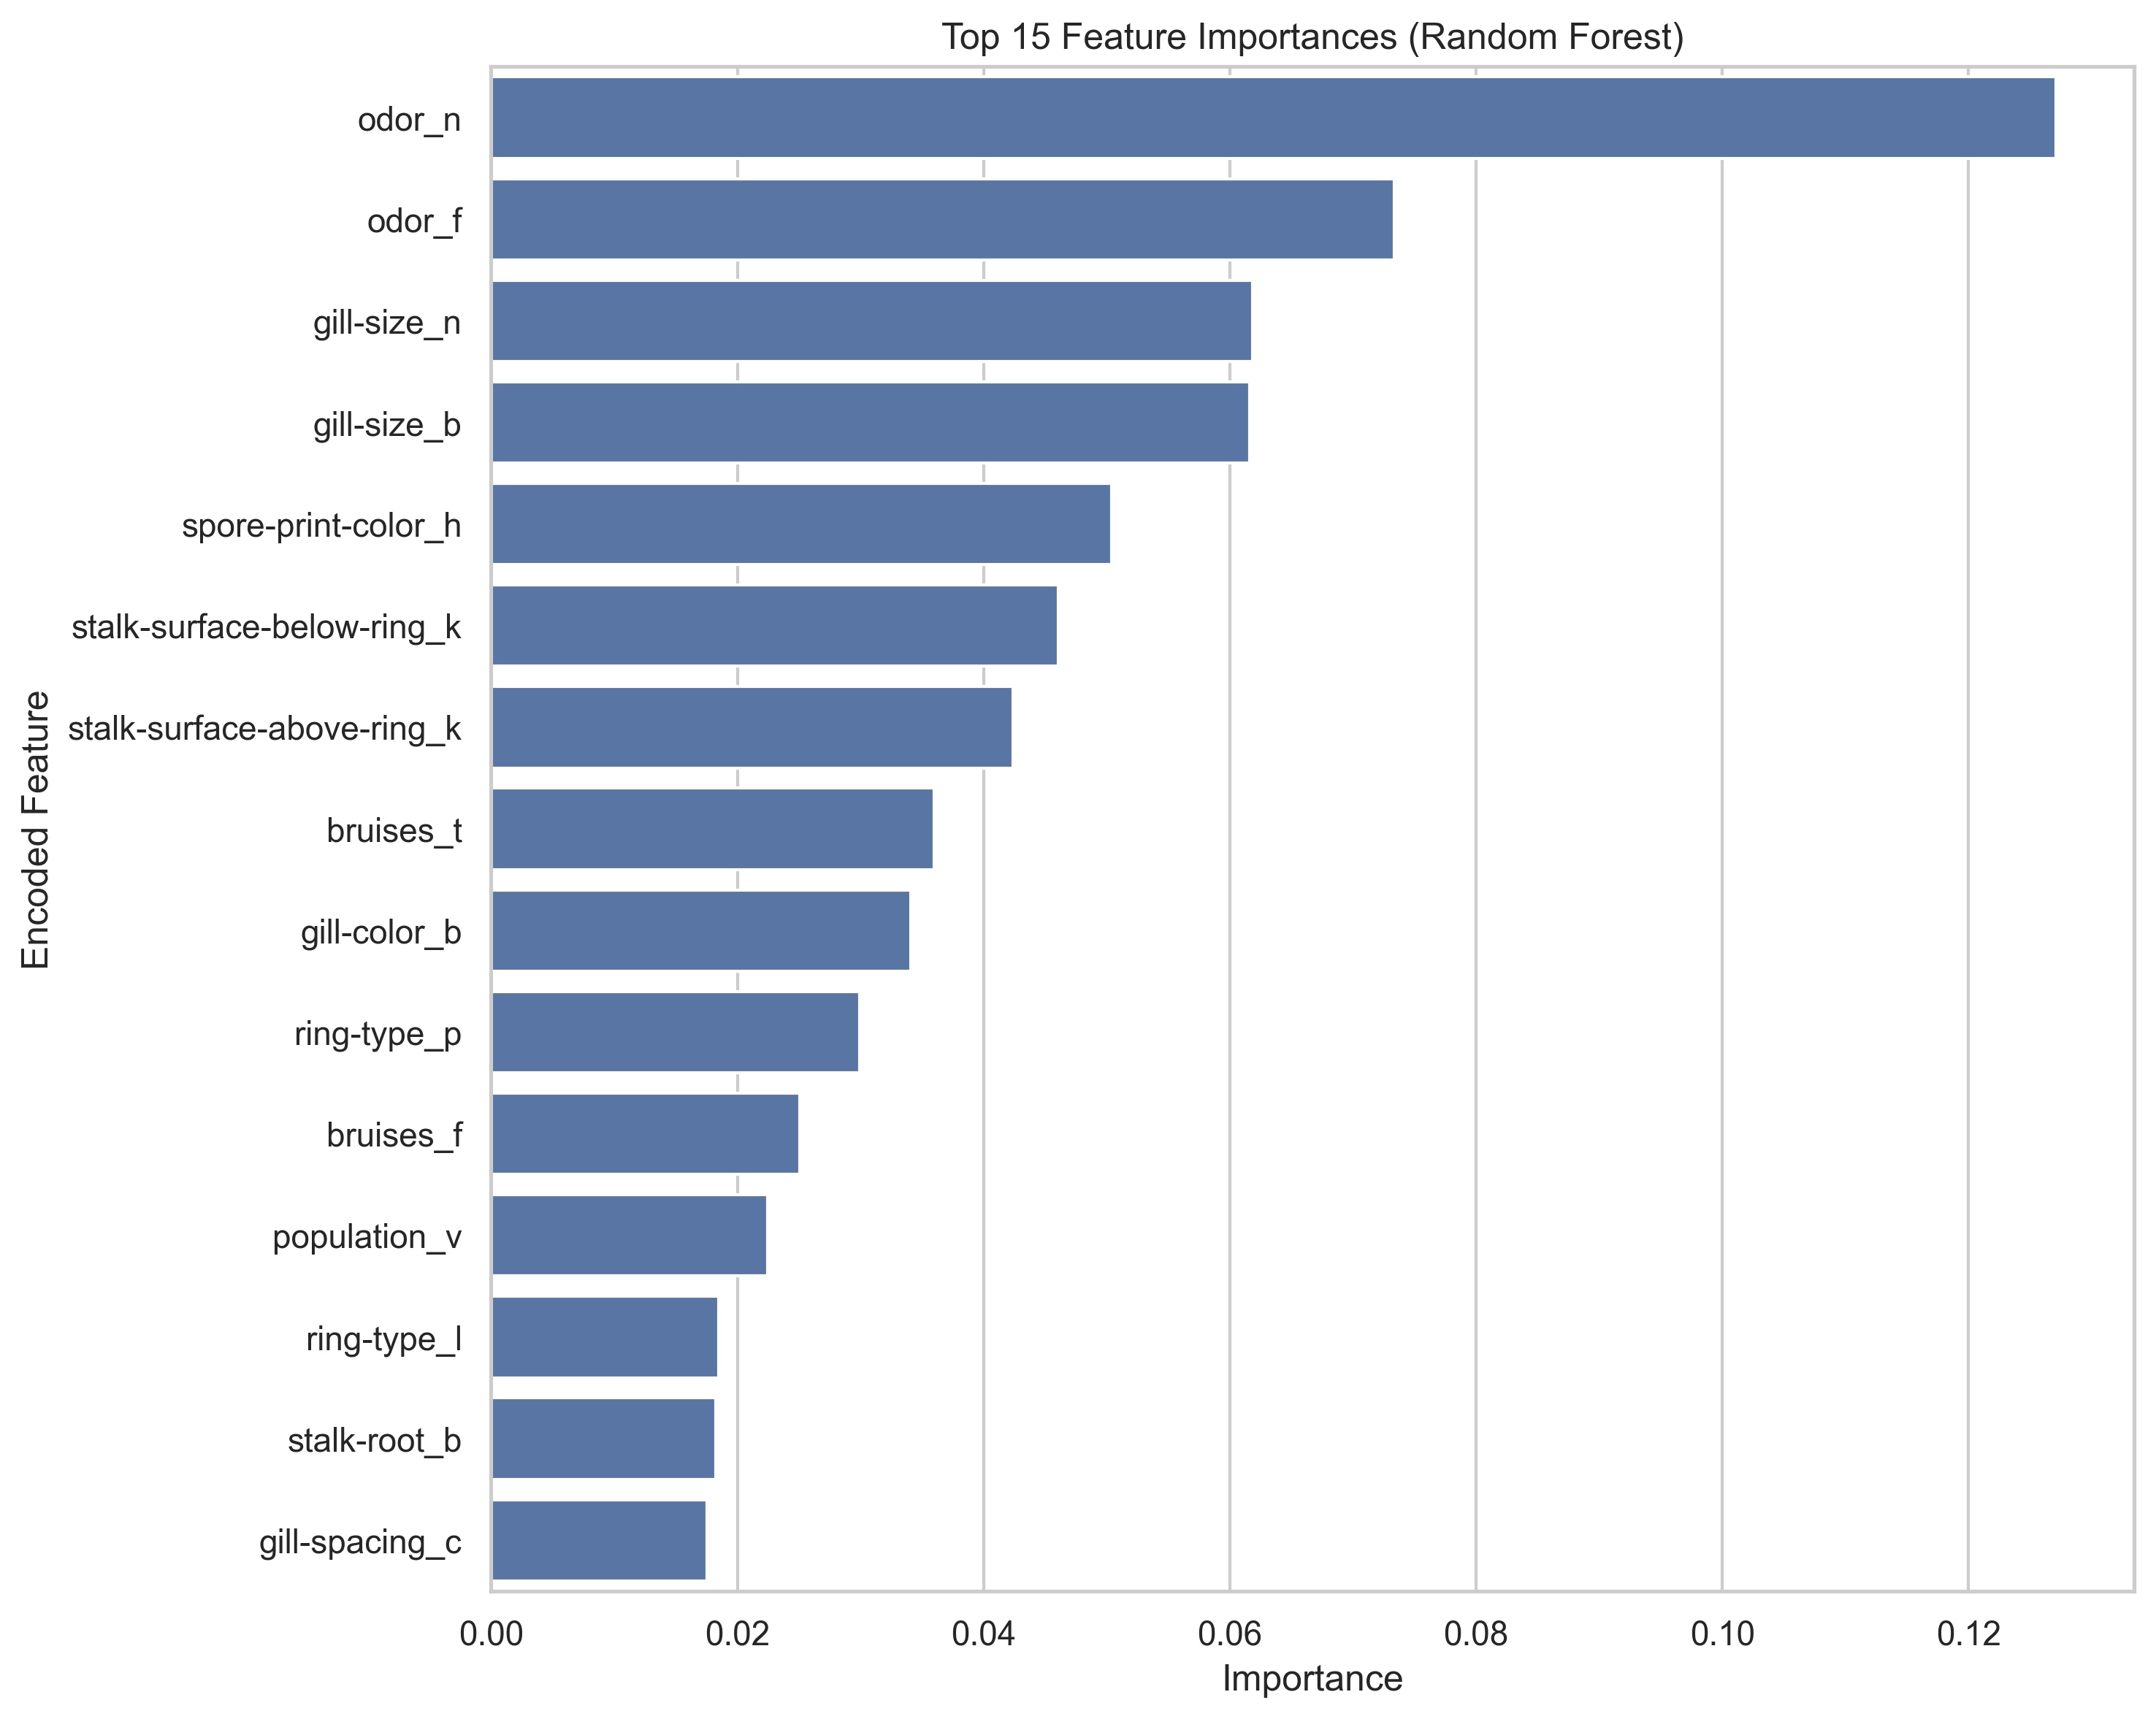

## Milestone 1 Report Preview

# Milestone 1 Report

## 1) Dataset Understanding
- Rows: 8124
- Columns: 23
- Duplicate rows: 0
- Class distribution: edible=4208, poisonous=3916

## 2) Preprocessing Applied
- Replaced '?' with missing values.
- Filled missing categorical values using most frequent value per feature.
- Added class-wise mode imputation artifact for comparison (`preprocessed_dataset_class_mode.csv`).
- Applied one-hot encoding to categorical features.
- Applied StandardScaler normalization for KNN and SVM models.
- Produced cleaned dataset table for analysis.

## 3) Outlier Detection
- Rarity-based outlier detection (top 1% rarity scores).
- Isolation Forest outlier detection (contamination=0.01).
- Combined outliers using union of both methods.

## 4) Visual Analysis
- Class distribution plot.
- Top feature associations with class (Cramer's V).
- Categorical association heatmap.
- Theil's U association heatmap.
- Top feature countplots by class.

## 5) Important Milestone-1 Files
- Tables in outputs/tables.
- Plots in outputs/plots.


## Final Project Summary Preview

# Final Project Summary

## Project
Mushroom Classification (Edible vs Poisonous)

## Dataset and Processing
- Original rows: 8124
- Rows used for modeling after outlier removal: 8018
- Features used: 22
- One-hot encoding applied for categorical features.
- StandardScaler normalization applied for KNN and SVM.

## Models Evaluated
```text
       model  accuracy  precision_poisonous  recall_poisonous  f1_poisonous  cv_accuracy_mean  cv_accuracy_std
RandomForest       1.0                  1.0               1.0           1.0            0.9043           0.1275
```

## Best Model
- Best model by poisonous F1: RandomForest
- Accuracy: 1.0000
- Precision (poisonous): 1.0000
- Recall (poisonous): 1.0000
- F1 (poisonous): 1.0000

## Most Prominent Factors
Top encoded features from Random Forest importance are saved in:
- outputs/tables/random_forest_feature_importance.csv
- outputs/plots/random_forest_feature_importance.png

## Deliverables Checklist
- Data understanding, preprocessing, outliers, EDA: completed.
- Multiple classifiers with metrics and comparison: completed.
- Feature prominence discussion material generated: completed.


Reports saved to: c:\Users\Ahmed Fahmy\Downloads\Projects\Data Mining\mushroom-classifier-project\outputs\20260304_204340_310404\reports
Timestamp run folder: c:\Users\Ahmed Fahmy\Downloads\Projects\Data Mining\mushroom-classifier-project\outputs\20260304_204340_310404


In [14]:
if 'RandomForest' in pipelines:
    importance_df = extract_random_forest_feature_importance(pipelines, feature_cols)
    importance_df.to_csv(dirs['tables'] / 'random_forest_feature_importance.csv', index=False)
    save_feature_importance_plot(importance_df, dirs['plots'] / 'random_forest_feature_importance.png')
else:
    importance_df = pd.DataFrame({
        'note': [
            'RandomForest feature importance was skipped because RandomForest was not selected in this run.'
        ]
    })
    importance_df.to_csv(dirs['tables'] / 'random_forest_feature_importance.csv', index=False)

best_model_name = comparison_df.iloc[0]['model']
best_model_metrics = comparison_df.iloc[0].to_dict()

milestone_1_report = build_milestone_1_report(
    rows_count=len(df),
    columns_count=len(df.columns),
    duplicate_rows=int(df.duplicated().sum()),
    edible_count=int((df[target_col] == 'e').sum()),
    poisonous_count=int((df[target_col] == 'p').sum()),
    outlier_contamination=OUTLIER_CONTAMINATION,
)

final_report = build_final_project_report(
    original_rows=len(df),
    modeling_rows=len(model_df),
    feature_count=len(feature_cols),
    comparison_df=comparison_df,
    best_model_name=best_model_name,
    best_model_metrics=best_model_metrics,
    random_forest_available='RandomForest' in pipelines,
)

milestone_report_path = dirs['reports'] / 'milestone_1_report.md'
final_report_path = dirs['reports'] / 'final_project_summary.md'

milestone_report_path.write_text(milestone_1_report, encoding='utf-8')
final_report_path.write_text(final_report, encoding='utf-8')

display(importance_df.head(15))
if (dirs['plots'] / 'random_forest_feature_importance.png').exists():
    display(Image(filename=str(dirs['plots'] / 'random_forest_feature_importance.png')))

display(Markdown('## Milestone 1 Report Preview'))
display(Markdown(milestone_report_path.read_text(encoding='utf-8')))

display(Markdown('## Final Project Summary Preview'))
display(Markdown(final_report_path.read_text(encoding='utf-8')))

print('Reports saved to:', dirs['reports'])
print('Timestamp run folder:', RUN_OUTPUT_DIR)

## 7) Done

All required outputs are generated under a timestamped run folder inside `outputs/`:
- `outputs/<timestamp>/tables`
- `outputs/<timestamp>/plots`
- `outputs/<timestamp>/reports`

Use the printed **Current run folder** from Cell 2 when collecting screenshots for submission.